# Chapter 10: Machine Learning Intro 2

In [22]:
import matplotlib.image as img
import matplotlib.pyplot as plt

import copy
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from os import listdir
from sklearn.model_selection import train_test_split
import seaborn as sns; sns.set()
from sklearn import metrics
from sklearn import preprocessing

## 10.1 Introduction & Problem Setting

Congratulations on making it this far! You have come a long way and are now ready to tackle a real-world problem. 🎯

Today you will apply what you have learned to a new and specific case: **fraud detection**. Imagine you work at a bank processing important documents. Each document must contain a signature, and your job is to identify which signatures are forged and which are genuine. Your boss has provided you with a collection of real signatures from previous documents as well as forged ones to help train your detection system.

## 10.2 Data loading

Load in the images from the training set. You cannot store all individual pixels in a dataframe efficiently. Instead, think creatively about what information might distinguish a real signature from a forged one. Extract features that capture the essence of each signature.

*Hint: Load a single signature first and display it. Look for distinguishing features: How spread out are the lines? How much of the image is filled versus empty? What is the overall darkness or lightness?*

### Guidance for Feature Extraction

To make this problem manageable, focus on these features from each signature:

**Color & Darkness:**
- Mean pixel value (average darkness of the signature)
- Standard deviation (how much the darkness varies, related to pen pressure)
- Minimum and maximum pixel values

**Ink Coverage:**
- Count of non-white pixels (how much ink was used)

**Distribution:**
- A histogram dividing pixel values into 10 bins (showing where most of the darkness is concentrated)

**Technical Notes:**
- You'll need to convert color images to grayscale using `cv2.cvtColor()` with `cv2.COLOR_BGR2GRAY`
- Import this library with: `import cv2`
- Flatten each image into a 1D array before calculating statistics
- Files are in: `signatures_data/signatures train/` (training) and `signatures_data/signatures test/` (testing)

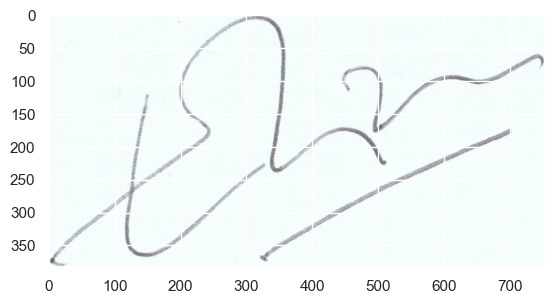

In [23]:
signature = img.imread("/Users/mohammedsadmanuddin/data analysis/Machine Learning 2/signatures_data/signatures test/001_02.PNG")
plt.imshow(signature)

In [24]:
import cv2

In [48]:
training_files = listdir('/Users/mohammedsadmanuddin/data analysis/Machine Learning 2/signatures_data/signatures train')
signature_train = pd.DataFrame(columns=["image", "mean", "std", "min", "max", "nonwhite_count", "hist_bin_1", "hist_bin_2", "hist_bin_3", "hist_bin_4", "hist_bin_5", "hist_bin_6", "hist_bin_7", "hist_bin_8", "hist_bin_9", "hist_bin_10"])
for i in training_files:
    signature_testfilepath = "/Users/mohammedsadmanuddin/data analysis/Machine Learning 2/signatures_data/signatures train/"+i
    new_signature = img.imread(signature_testfilepath)
    if len(new_signature.shape) == 3:
        gray = cv2.cvtColor(new_signature,cv2.COLOR_BGR2GRAY).flatten()
    else:
        gray = new_signature.flatten()
    mean_val = np.mean(gray)
    std_val = np.std(gray)
    min_val = np.min(gray)
    max_val = np.max(gray)
    nonwhite_count = np.count_nonzero(gray)
    hist = np.histogram(gray, bins=10, range=(0, 1))

    signature_train.loc[len(signature_train)] = {
                "image": i,
                "mean": mean_val,
                "std": std_val,
                "min": min_val,
                "max": max_val,
                "nonwhite_count": nonwhite_count,
                "hist_bin_1": hist[0][0],
                "hist_bin_2": hist[0][1],
                "hist_bin_3": hist[0][2],
                "hist_bin_4": hist[0][3],
                "hist_bin_5": hist[0][4],
                "hist_bin_6": hist[0][5],
                "hist_bin_7": hist[0][6],
                "hist_bin_8": hist[0][7],
                "hist_bin_9": hist[0][8],
                "hist_bin_10": hist[0][9]
            }
signature_train.head(5)


,image,mean,std,min,max,nonwhite_count,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7,hist_bin_8,hist_bin_9,hist_bin_10
0,0104014_02.png,0.948621,0.131839,0.000000,0.989474,170538,164,310,731,1834,2509,2526,2632,2627,2982,154228
1,01_0107046.PNG,0.948979,0.128536,0.000000,0.989474,176075,209,185,502,1509,2728,3283,3105,2638,2557,159369
2,03_0211044.PNG,0.907463,0.215055,0.000000,0.989474,123013,1951,1534,2253,2914,2419,1557,1227,1140,1728,106357
3,05_043.png,0.928897,0.141377,0.298588,0.997765,75753,0,0,2,100,1795,3982,2849,1736,1654,63635
4,004_03.PNG,0.945763,0.123345,0.336357,0.997765,70664,0,0,0,59,1441,2679,1448,1087,1258,62692


### Building Your Feature DataFrame

Create a DataFrame where each row represents one signature with columns for each feature (mean, std, min, max, nonwhite_count, and hist_bin_1 through hist_bin_10). Loop through all training files and calculate these statistics for each image. Your final DataFrame should have 16 columns: "image" (filename) + 15 features.

### Loading the Labels

The signatures have labels stored in `signatures_data/signatures.csv`. This file uses a special delimiter (%) to separate columns. When you read it, the columns are:
- `image`: the filename matching your feature data
- `signature id`: which person created the signature
- `forged`: whether it's genuine (False) or forged (True)

After loading and merging with your features, you'll create X (features) and Y (the 'forged' column for training).

Next, build your outcome vector using the provided CSV file. Make sure to merge it correctly with the image data by matching on the image filenames. We will predict the 'forged' column, which tells us whether each signature is genuine (False) or forged (True).

In [49]:
outcome = pd.read_csv("/Users/mohammedsadmanuddin/data analysis/Machine Learning 2/signatures_data/signatures.csv",header=0,sep="%")
outcome.head(10)

,image,signature id,forged
0,001_01.PNG,1,False
1,001_02.PNG,1,False
2,001_03.PNG,1,False
3,001_04.PNG,1,False
4,001_05.PNG,1,False
5,001_06.PNG,1,False
6,001_07.PNG,1,False
7,001_08.PNG,1,False
8,001_09.PNG,1,False
9,001_10.PNG,1,False


In [50]:
final_train = pd.merge(signature_train,outcome,left_on="image",right_on="image")
final_train.head()

,image,mean,std,min,max,nonwhite_count,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7,hist_bin_8,hist_bin_9,hist_bin_10,signature id,forged
0,0104014_02.png,0.948621,0.131839,0.000000,0.989474,170538,164,310,731,1834,2509,2526,2632,2627,2982,154228,14,True
1,01_0107046.PNG,0.948979,0.128536,0.000000,0.989474,176075,209,185,502,1509,2728,3283,3105,2638,2557,159369,46,True
2,03_0211044.PNG,0.907463,0.215055,0.000000,0.989474,123013,1951,1534,2253,2914,2419,1557,1227,1140,1728,106357,44,True
3,05_043.png,0.928897,0.141377,0.298588,0.997765,75753,0,0,2,100,1795,3982,2849,1736,1654,63635,43,False
4,004_03.PNG,0.945763,0.123345,0.336357,0.997765,70664,0,0,0,59,1441,2679,1448,1087,1258,62692,4,False


In [51]:
X_train = final_train.drop(columns=["signature id","forged","image"])
Y_train = final_train["forged"]

## 10.3 Model Creation & Evaluation

Now train a Random Forest classifier just as we did in the main notebook. Then load the test set using the same feature extraction process and evaluate how well your model can detect forged signatures.

In [52]:
ML_model = RandomForestClassifier()
ML_model.fit(X_train,Y_train)

RandomForestClassifier()

In [55]:
testing_files = listdir('/Users/mohammedsadmanuddin/data analysis/Machine Learning 2/signatures_data/signatures test')
signature_test = pd.DataFrame(columns=["image", "mean", "std", "min", "max", "nonwhite_count", "hist_bin_1", "hist_bin_2", "hist_bin_3", "hist_bin_4", "hist_bin_5", "hist_bin_6", "hist_bin_7", "hist_bin_8", "hist_bin_9", "hist_bin_10"])
for i in testing_files:
    signature_testfilepath = "/Users/mohammedsadmanuddin/data analysis/Machine Learning 2/signatures_data/signatures test/"+i
    new_signature = img.imread(signature_testfilepath)
    if len(new_signature.shape) == 3:
        gray = cv2.cvtColor(new_signature,cv2.COLOR_BGR2GRAY).flatten()
    else:
        gray = new_signature.flatten()
    mean_val = np.mean(gray)
    std_val = np.std(gray)
    std_val = np.std(gray)
    min_val = np.min(gray)
    max_val = np.max(gray)
    nonwhite_count = np.count_nonzero(gray)
    hist = np.histogram(gray, bins=10, range=(0, 1))

    signature_test.loc[len(signature_test)] = {
                "image": i,
                "mean": mean_val,
                "std": std_val,
                "min": min_val,
                "max": max_val,
                "nonwhite_count": nonwhite_count,
                "hist_bin_1": hist[0][0],
                "hist_bin_2": hist[0][1],
                "hist_bin_3": hist[0][2],
                "hist_bin_4": hist[0][3],
                "hist_bin_5": hist[0][4],
                "hist_bin_6": hist[0][5],
                "hist_bin_7": hist[0][6],
                "hist_bin_8": hist[0][7],
                "hist_bin_9": hist[0][8],
                "hist_bin_10": hist[0][9]
            }
signature_test.head(5)


,image,mean,std,min,max,nonwhite_count,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7,hist_bin_8,hist_bin_9,hist_bin_10
0,0210012_04.png,0.956812,0.122169,0.000000,0.989474,269352,305,556,1024,2548,3435,3086,2402,1981,2524,251499
1,004_17.PNG,0.946317,0.136351,0.000000,0.989474,70685,42,95,263,896,1369,1333,975,823,1024,63866
2,08_060.png,0.959043,0.088673,0.345726,0.998212,228177,0,0,0,31,827,2854,5609,7296,6781,204779
3,01_0117057.PNG,0.927315,0.181215,0.000000,0.989474,79415,556,675,958,1496,1431,1093,932,936,1175,70174
4,04_046.png,0.942162,0.123023,0.337827,0.998212,141742,0,0,0,51,1868,5705,4921,3076,2587,123534


In [56]:
final_test = pd.merge(signature_test,outcome,left_on="image",right_on="image")
final_test.head()

,image,mean,std,min,max,nonwhite_count,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7,hist_bin_8,hist_bin_9,hist_bin_10,signature id,forged
0,0210012_04.png,0.956812,0.122169,0.000000,0.989474,269352,305,556,1024,2548,3435,3086,2402,1981,2524,251499,12,True
1,004_17.PNG,0.946317,0.136351,0.000000,0.989474,70685,42,95,263,896,1369,1333,975,823,1024,63866,4,False
2,08_060.png,0.959043,0.088673,0.345726,0.998212,228177,0,0,0,31,827,2854,5609,7296,6781,204779,60,False
3,01_0117057.PNG,0.927315,0.181215,0.000000,0.989474,79415,556,675,958,1496,1431,1093,932,936,1175,70174,57,True
4,04_046.png,0.942162,0.123023,0.337827,0.998212,141742,0,0,0,51,1868,5705,4921,3076,2587,123534,46,False


In [57]:
X_test = final_test.drop(columns=["signature id","forged","image"])
Y_test = final_test["forged"]

### Evaluating Your Model

After training your RandomForestClassifier on X_train and Y_train, and making predictions on X_test:

1. Create a confusion matrix like in the main notebook (with labels [True, False])
2. Interpret the results:
   - **Top-left (True predicted True)**: Correctly identified forged signatures ✓
   - **Bottom-right (False predicted False)**: Correctly identified genuine signatures ✓
   - **Top-right (True predicted False)**: Missed a forged signature (false negative) ✗
   - **Bottom-left (False predicted True)**: Falsely accused a genuine signature (false positive) ✗

For fraud detection, which type of error is worse?

Text(0.5, 77.24999999999999, 'Pred')

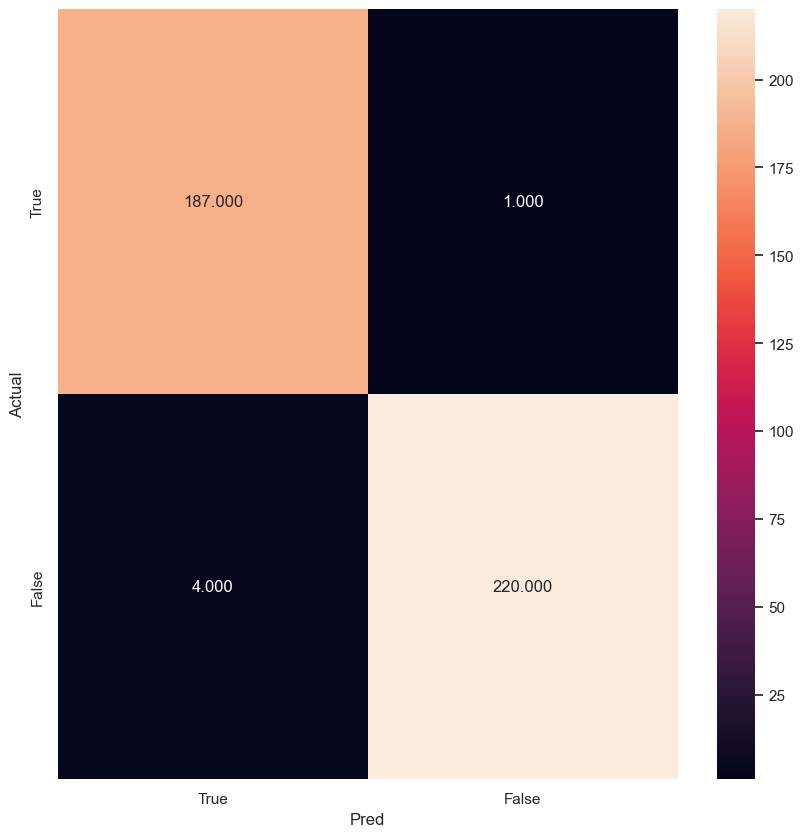

In [59]:
Y_pred = ML_model.predict(X_test)
labels = [True,False]
plt.figure(figsize=(10,10))
cm = metrics.confusion_matrix(Y_test,Y_pred,labels=labels)
sns.heatmap(cm,annot=True,fmt="0.3f",xticklabels=labels, yticklabels=labels)
plt.ylabel("Actual")
plt.xlabel("Pred")

## 10.4 Putting Your Model in Action

A new document arrives: "bank_statement.pdf". Let's use your trained model to determine if the signature is genuine or forged. 🔍

First, let's display the signature image from the document.

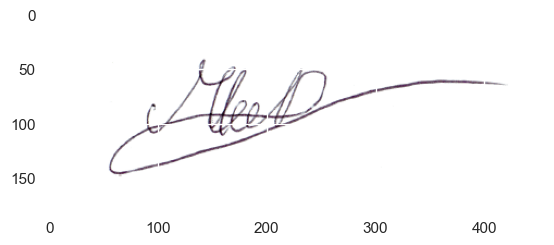

In [63]:
bank_signature = img.imread("/Users/mohammedsadmanuddin/data analysis/Machine Learning 2/signatures_data/screenshot_signature_bank_statement.png")
plt.imshow(bank_signature)

In [64]:
X_signature = pd.DataFrame(columns=["mean", "std", "min", "max", "nonwhite_count", "hist_bin_1", "hist_bin_2", "hist_bin_3", "hist_bin_4", "hist_bin_5", "hist_bin_6", "hist_bin_7", "hist_bin_8", "hist_bin_9", "hist_bin_10"])

for i in testing_files:
        signature_filepath = "signatures_data/signatures test/" + i
        signature = img.imread(signature_filepath)

        if len(signature.shape) == 3:
            gray = cv2.cvtColor(signature, cv2.COLOR_BGR2GRAY).flatten()
        else:
            gray = signature.flatten()

        mean_val = np.mean(gray)
        std_val = np.std(gray)
        min_val = np.min(gray)
        max_val = np.max(gray)
        nonwhite_count = np.count_nonzero(gray)
        hist = np.histogram(gray, bins=10, range=(0, 1))

        X_signature.loc[0] = {
                    "mean": mean_val,
                    "std": std_val,
                    "min": min_val,
                    "max": max_val,
                    "nonwhite_count": nonwhite_count,
                    "hist_bin_1": hist[0][0],
                    "hist_bin_2": hist[0][1],
                    "hist_bin_3": hist[0][2],
                    "hist_bin_4": hist[0][3],
                    "hist_bin_5": hist[0][4],
                    "hist_bin_6": hist[0][5],
                    "hist_bin_7": hist[0][6],
                    "hist_bin_8": hist[0][7],
                    "hist_bin_9": hist[0][8],
                    "hist_bin_10": hist[0][9]
                }

X_signature.head()

,mean,std,min,max,nonwhite_count,hist_bin_1,hist_bin_2,hist_bin_3,hist_bin_4,hist_bin_5,hist_bin_6,hist_bin_7,hist_bin_8,hist_bin_9,hist_bin_10
0,0.932536,0.140411,0.291596,0.997765,142569,0,0,1,330,3664,7428,3773,2524,2681,122168


In [ ]:
ML_model.predict(X_signature) 

array([False])

SO the signature is forged..